In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9244 - loss: 0.2625 - val_accuracy: 0.9573 - val_loss: 0.1418
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9660 - loss: 0.1145 - val_accuracy: 0.9672 - val_loss: 0.1093
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0797 - val_accuracy: 0.9741 - val_loss: 0.0868
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9820 - loss: 0.0597 - val_accuracy: 0.9749 - val_loss: 0.0789
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9851 - loss: 0.0467 - val_accuracy: 0.9782 - val_loss: 0.0767


In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9782 - loss: 0.0767
Test Accuracy: 0.9782000184059143


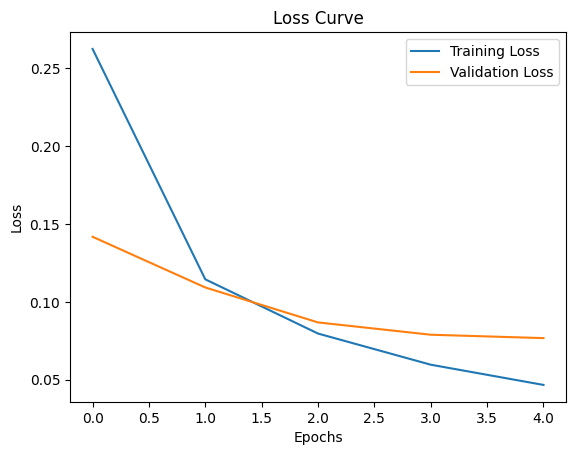

In [6]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


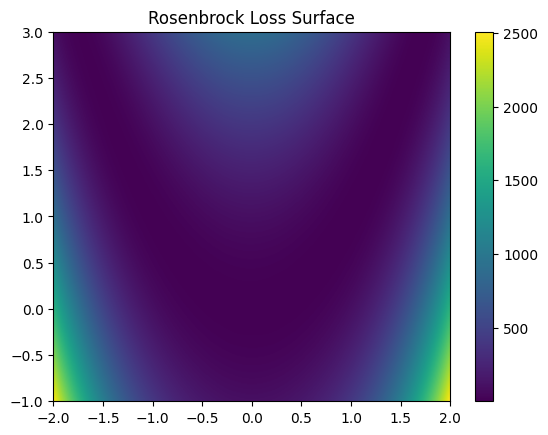

In [7]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

plt.figure()
plt.imshow(Z, extent=[-2,2,-1,3], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Rosenbrock Loss Surface")
plt.show()


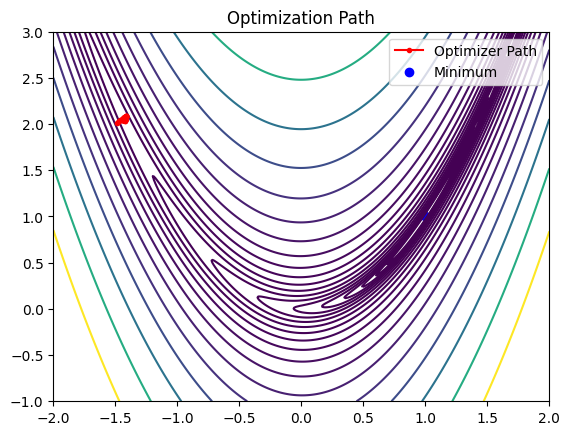

In [8]:
x_var = tf.Variable([-1.5, 2.0], dtype=tf.float32)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

path = []

for i in range(50):
    with tf.GradientTape() as tape:
        loss = (1 - x_var[0])**2 + 100 * (x_var[1] - x_var[0]**2)**2
    grads = tape.gradient(loss, [x_var])
    optimizer.apply_gradients(zip(grads, [x_var]))
    path.append(x_var.numpy().copy())

path = np.array(path)


plt.figure()
levels = np.logspace(-1, 3, 20)
plt.contour(X, Y, Z, levels=levels)

plt.plot(path[:,0], path[:,1], 'r.-', label='Optimizer Path')
plt.scatter(1, 1, color='blue', label='Minimum')

plt.title("Optimization Path")
plt.legend()
plt.show()